In [7]:
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

%cd {project_root}

/home/shadeform/Psi0-Waldo


/home/shadeform/Psi0-Waldo/.venv-psi/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [8]:
import torch
import numpy as np
from pathlib import Path
from psi.utils import parse_args_to_tyro_config, seed_everything, move_to_device, batchify
from psi.config.config import LaunchConfig

In [9]:
ckpt_step = 40000
run_dir = Path(".runs/finetune/stackcups.real.flow1000.cosine.lr1.0e-04.b128.gpus8.2604160048")
config_:LaunchConfig = parse_args_to_tyro_config(run_dir / "argv.txt") # type: ignore
conf = (run_dir / "run_config.json").open("r").read()
launch_config = config_.model_validate_json(conf)

In [10]:
seed_everything(launch_config.seed or 42)

In [11]:
device = "cuda:0"

In [12]:
from psi.models.psi0 import Psi0Model 
psi0 = Psi0Model.from_pretrained(run_dir, ckpt_step, launch_config, device=device)
psi0.to(device)
psi0.eval()
print("Model loaded successfully.")

You are attempting to use Flash Attention 2 without specifying a torch dtype. This might lead to unexpected behaviour
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[04:54:05 04/16] INFO     | >> [*] Resized model token embeddings to 153792                            ]8;id=975055;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=401768;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py#1550\1550]8;;\

                 INFO     | >> [*] loaded vlm_backbone checkpoint successfully.                        ]8;id=993752;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=976513;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py#1553\1553]8;;\

[04:54:08 04/16] INFO     | >> [*] Total ActionTransformerModel parameters: 497,719,256                ]8;id=120785;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=101754;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py#1510\1510]8;;\

                 INFO     | >> [*] Total VLM Backbone parameters: 2,131,333,120                        ]8;id=161681;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=974824;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py#1514\1514]8;;\

                 INFO     | >> [*] loaded action head checkpoint successfully.                         ]8;id=422394;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py\psi0.py]8;;\:]8;id=225693;file:///home/shadeform/Psi0-Waldo/src/psi/models/psi0.py#1571\1571]8;;\

Model loaded successfully.


In [13]:
from psi.config.data_lerobot import LerobotDataConfig
data_cfg: LerobotDataConfig = launch_config.data # type: ignore

from psi.config.model_psi0 import Psi0ModelConfig
model_cfg: Psi0ModelConfig = launch_config.model # type: ignore

In [14]:
maxmin = data_cfg.transform.field

In [15]:
transform_kwargs=dict(
    vlm_processor=psi0.vlm_processor,
)

In [16]:
dataset = data_cfg(split="train", transform_kwargs=transform_kwargs)

[04:54:11 04/16] INFO     | >> PyTorch version 2.7.0 available.                                        ]8;id=557966;file:///home/shadeform/Psi0-Waldo/.venv-psi/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=879618;file:///home/shadeform/Psi0-Waldo/.venv-psi/lib/python3.10/site-packages/datasets/config.py#54\54]8;;\

                 INFO     | >> TensorFlow version 2.15.0 available.                                   ]8;id=837357;file:///home/shadeform/Psi0-Waldo/.venv-psi/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=856457;file:///home/shadeform/Psi0-Waldo/.venv-psi/lib/python3.10/site-packages/datasets/config.py#112\112]8;;\

In [17]:
dataset.raw_dataset.meta

LeRobotDatasetMetadata({
    Repository ID: 'G1_Brainco_StackCups',
    Total episodes: '102',
    Total frames: '22777',
    Features: '['observation.state', 'action', 'observation.velocity', 'observation.effort', 'observation.arm_ddq', 'observation.arm_external_torque', 'observation.arm_compensation_torque', 'observation.cartesian_pos', 'observation.cartesian_axis_angle', 'observation.cartesian_vel', 'observation.cartesian_accel', 'observation.cartesian_external_wrench', 'observation.rotor_temperature', 'observation.fingertip_positions', 'observation.tactile_normal_force', 'observation.tactile_tangential_force', 'observation.tactile_tangential_direction', 'observation.tactile_proximity', 'observation.camera_pose_head', 'observation.camera_pose_surround', 'action.arm_velocity', 'action.arm_effort', 'action.arm_ddq', 'action.arm_compensation_torque', 'action.cartesian_pos', 'action.cartesian_axis_angle', 'action.cartesian_vel', 'action.cartesian_accel', 'action.fingertip_positions', 'o

In [18]:
eps_idx = np.random.randint(0, dataset.raw_dataset.meta.total_episodes)
print(eps_idx)

88


In [19]:
start_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["from"][eps_idx].item()
end_frame_idx = dataset.raw_dataset.base_dataset.episode_data_index["to"][eps_idx].item()

In [20]:
print(start_frame_idx, end_frame_idx)
print("num frames in this episode:", end_frame_idx - start_frame_idx)

19540 19800
num frames in this episode: 260


In [21]:
avg_action_errors_denormed_list = []

# StackCups: 26 real dims (padded to 36)
# [0:7]   left arm joints
# [7:14]  right arm joints
# [14:20] left hand joints
# [20:26] right hand joints
# [26:36] padding (zeros)
labels_denormed = [
    "left_arm",
    "right_arm",
    "left_hand",
    "right_hand",
]

stride = 4
for i in range(start_frame_idx, end_frame_idx, stride):
    frame = dataset[i]
    images = frame["raw_images"]
    batch_images = [images]
    instruction = frame['instruction']
    batch_instructions = [instruction]

    states = frame['states']
    batch_states = torch.from_numpy(states).unsqueeze(0).to(device)

    pred_actions = psi0.predict_action(
        observations=batch_images, 
        states=batch_states, 
        instructions=batch_instructions, 
        num_inference_steps=10, 
        traj2ds=None
    )
    
    gt_action = torch.from_numpy(frame["raw_actions"]).unsqueeze(0).to(device)
    denormalized_pred_actions = maxmin.denormalize(pred_actions)

    error = denormalized_pred_actions - gt_action
    error_l1 = error.detach().abs().cpu().numpy().reshape(-1, gt_action.shape[-1])

    avg_action_errors_denormed = error_l1.mean(0)
    avg_action_errors_denormed_list.append(avg_action_errors_denormed)

avg_action_errors_denormed_list = np.stack(avg_action_errors_denormed_list, axis=0)
avg_action_errors_denormed = avg_action_errors_denormed_list.mean(axis=0)

# Split into semantic groups: left_arm(7), right_arm(7), left_hand(6), right_hand(6)
avg_action_errors_denormed_split = np.split(
    avg_action_errors_denormed[:26], [7, 14, 20], axis=-1
)

print("\n---------------------------\n")
for i in range(len(avg_action_errors_denormed_split)):
    print(f"denormed_err_l1_{labels_denormed[i]} {avg_action_errors_denormed_split[i].shape}:  {np.linalg.norm(avg_action_errors_denormed_split[i]):.6f}")


---------------------------

denormed_err_l1_left_arm (7,):  0.005744
denormed_err_l1_right_arm (7,):  0.046227
denormed_err_l1_left_hand (6,):  0.004461
denormed_err_l1_right_hand (6,):  0.016467


In [22]:
!uv pip install matplotlib

Using Python 3.10.12 environment at: .venv-psi
Checked 1 package in 5ms


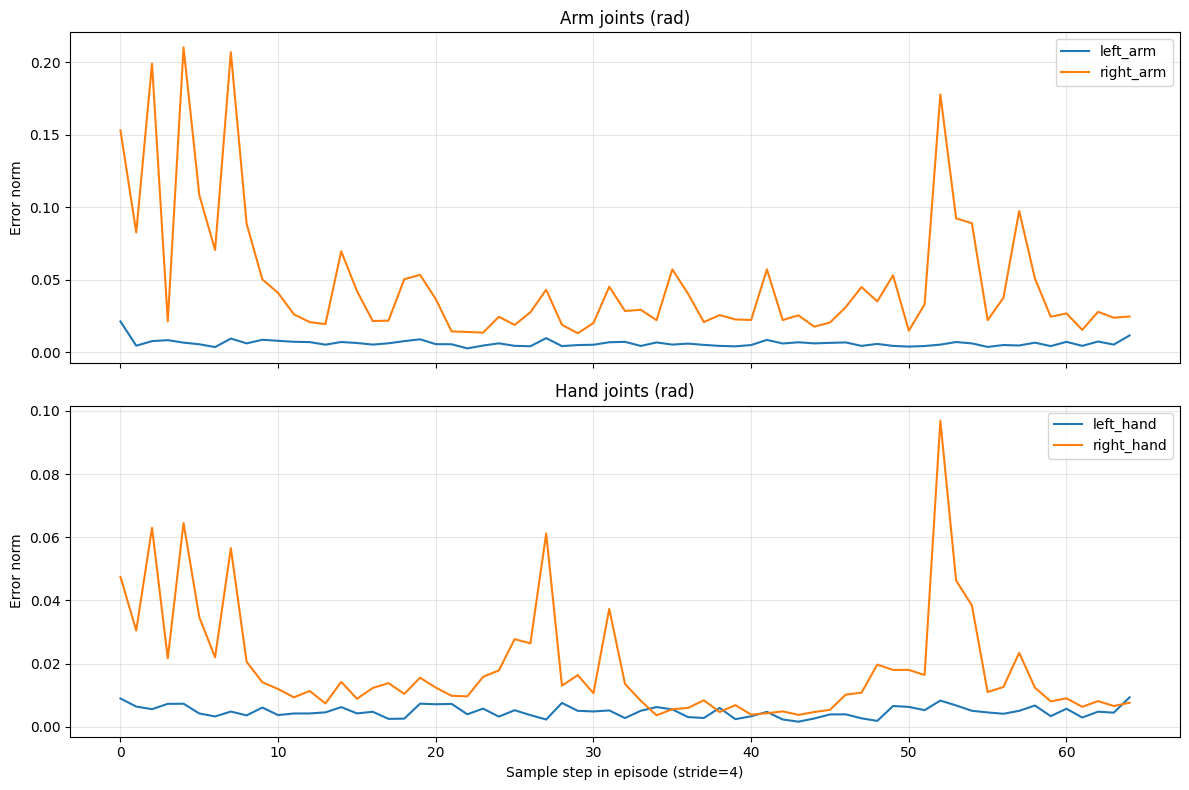

In [25]:
import matplotlib.pyplot as plt

# StackCups: 26 real dims — left_arm(7), right_arm(7), left_hand(6), right_hand(6)
group_slices = [7, 14, 20, 26]
error_groups = np.split(avg_action_errors_denormed_list[:, :26], group_slices[:-1], axis=-1)

per_label_curves = [np.linalg.norm(group, axis=-1) for group in error_groups]
curve_map = dict(zip(labels_denormed, per_label_curves))

plot_groups = [
    ("Arm joints (rad)", ["left_arm", "right_arm"]),
    ("Hand joints (rad)", ["left_hand", "right_hand"]),
]

fig, axes = plt.subplots(len(plot_groups), 1, figsize=(12, 8), sharex=True)

for ax, (title, keys) in zip(axes, plot_groups):
    for key in keys:
        curve = curve_map.get(key)
        if curve is None:
            continue
        ax.plot(curve, label=key)
    ax.set_title(title)
    ax.set_ylabel("Error norm")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Sample step in episode (stride=4)")
plt.tight_layout()
plt.savefig("openloop_eval_stackcups.png", dpi=150)
plt.show()